# Internal Notifications API — Python notebook

This notebook follows the same practical style used by the public InfoDengue service tutorials: configure the API endpoint, build a small reusable function, request data with query parameters, convert the JSON response to a tabular structure, and run simple exploratory analyses.

Endpoint used here:

```text
GET /api/internal/notifications/
```

Authentication uses:

```text
Authorization: Token <TOKEN>
```

Before running the notebook, set:

```bash
export NOTIFICATION_API_TOKEN="<your-token>"
export NOTIFICATION_API_BASE_URL="http://s2.dengue.mat.br"
```


In [3]:
from __future__ import annotations

import os
from dataclasses import dataclass
from typing import Any

import matplotlib.pyplot as plt
import pandas as pd
import requests
from requests import Response, Session

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)


## 1. API configuration

In [8]:
@dataclass(frozen=True)
class APIConfig:
    base_url: str
    token: str
    timeout_seconds: int = 30

    @property
    def notifications_url(self) -> str:
        return f"{self.base_url.rstrip('/')}/api/internal/notifications/"


config = APIConfig(
    base_url=os.getenv("NOTIFICATION_API_BASE_URL", "http://s2.dengue.mat.br"),
    token=os.getenv("NOTIFICATION_API_TOKEN", "your-token"),
)


In [9]:
def build_session(config: APIConfig) -> Session:
    session = requests.Session()
    session.headers.update(
        {
            "Authorization": f"Token {config.token}",
            "Accept": "application/json",
        }
    )
    return session


session = build_session(config)


## 2. Request helper

Supported endpoint parameters:

- `municipio_geocodigo`
- `cid10`
- `year`
- `epiweek_start`
- `epiweek_end`
- `date_start`
- `date_end`
- `limit`
- `offset`
- `include_count`

`include_count` is optional because count queries can be expensive in large tables.


In [10]:
def raise_for_api_error(response: Response) -> None:
    try:
        response.raise_for_status()
    except requests.HTTPError as exc:
        raise RuntimeError(
            f"API request failed with status {response.status_code}: "
            f"{response.text[:1_000]}"
        ) from exc


def get_notifications(
    session: Session,
    config: APIConfig,
    *,
    municipio_geocodigo: int | None = None,
    cid10: str | None = None,
    year: int | None = None,
    epiweek_start: int | None = None,
    epiweek_end: int | None = None,
    date_start: str | None = None,
    date_end: str | None = None,
    limit: int = 1_000,
    offset: int = 0,
    include_count: bool = False,
) -> dict[str, Any]:
    params: dict[str, Any] = {
        "limit": limit,
        "offset": offset,
        "include_count": str(include_count).lower(),
    }

    optional_params = {
        "municipio_geocodigo": municipio_geocodigo,
        "cid10": cid10,
        "year": year,
        "epiweek_start": epiweek_start,
        "epiweek_end": epiweek_end,
        "date_start": date_start,
        "date_end": date_end,
    }
    params.update(
        {key: value for key, value in optional_params.items() if value is not None}
    )

    response = session.get(
        config.notifications_url,
        params=params,
        timeout=config.timeout_seconds,
    )
    raise_for_api_error(response)
    return response.json()


def notifications_to_dataframe(payload: dict[str, Any]) -> pd.DataFrame:
    dataframe = pd.DataFrame.from_records(payload.get("results", []))

    for column in ["dt_notific", "dt_sin_pri", "dt_digita"]:
        if column in dataframe.columns:
            dataframe[column] = pd.to_datetime(dataframe[column], errors="coerce")

    for column in [
        "id",
        "municipio_geocodigo",
        "se_notif",
        "ano_notif",
        "classi_fin",
        "criterio",
        "id_distrit",
        "id_bairro",
        "nu_notific",
    ]:
        if column in dataframe.columns:
            dataframe[column] = pd.to_numeric(dataframe[column], errors="coerce")

    return dataframe


## 3. Basic request: dengue notifications for Rio de Janeiro

In [11]:
payload = get_notifications(
    session,
    config,
    municipio_geocodigo=3304557,
    cid10="A90",
    year=2025,
    limit=10,
    offset=0,
)

df = notifications_to_dataframe(payload)
df


,id,municipio_geocodigo,dt_notific,dt_sin_pri,dt_digita,se_notif,ano_notif,classi_fin,criterio,cid10_codigo,id_distrit,id_bairro,nm_bairro,nu_notific
0,1524117162,3304557,2026-01-03,2025-12-30,2026-01-19,53,2025,5.0,2.0,A90,138.0,118.0,CIDADE DE DEUS,6426846
1,1521769543,3304557,2026-01-03,2026-01-01,2026-01-05,53,2025,5.0,1.0,A90,136.0,74.0,VILA DA PENHA,6417545
2,1521747253,3304557,2026-01-03,2026-01-03,2026-01-06,53,2025,5.0,1.0,A90,132.0,0.0,RAMOS,6610617
3,1521563281,3304557,2026-01-03,2025-12-25,2026-01-08,53,2025,5.0,1.0,A90,148.0,152.0,BARRA DE GUARATIBA,6529897
4,1521441356,3304557,2026-01-03,2026-01-01,2026-01-13,53,2025,10.0,2.0,A90,125.0,6.0,CATUMBI,2299693
5,1521079529,3304557,2026-01-03,2026-01-01,2026-01-07,53,2025,5.0,1.0,A90,134.0,51.0,JACARE,6612215
6,1514752519,3304557,2026-01-03,2025-12-15,2026-01-03,53,2025,5.0,1.0,A90,140.0,144.0,CAMPO GRANDE,6613489
7,1514727713,3304557,2026-01-03,2026-01-01,2026-01-03,53,2025,10.0,1.0,A90,139.0,141.0,BANGU,6605423
8,1540822783,3304557,2026-01-02,2025-12-30,2026-02-03,53,2025,5.0,1.0,A90,130.0,33.0,TIJUCA,6527900
9,1521886683,3304557,2026-01-02,2025-12-30,2026-01-08,53,2025,5.0,1.0,A90,130.0,33.0,TIJUCA,6527453


## 4. Request total count only when needed

In [12]:
payload_with_count = get_notifications(
    session,
    config,
    municipio_geocodigo=3304557,
    cid10="A90",
    year=2025,
    limit=10,
    offset=0,
    include_count=True,
)

payload_with_count.get("count")


31205

## 5. Fetch multiple pages safely

In [13]:
def get_notification_pages(
    session: Session,
    config: APIConfig,
    *,
    page_size: int = 1_000,
    max_rows: int = 5_000,
    **filters: Any,
) -> pd.DataFrame:
    frames: list[pd.DataFrame] = []

    for offset in range(0, max_rows, page_size):
        payload = get_notifications(
            session,
            config,
            limit=page_size,
            offset=offset,
            **filters,
        )
        page = notifications_to_dataframe(payload)

        if page.empty:
            break

        frames.append(page)

        if len(page) < page_size:
            break

    if not frames:
        return pd.DataFrame()

    return pd.concat(frames, ignore_index=True)


df_pages = get_notification_pages(
    session,
    config,
    municipio_geocodigo=3304557,
    cid10="A90",
    year=2025,
    page_size=500,
    max_rows=2_000,
)

df_pages.shape


(2000, 14)

## 6. Simple analyses

In [14]:
summary = {
    "rows": len(df_pages),
    "date_min": df_pages["dt_notific"].min() if "dt_notific" in df_pages else None,
    "date_max": df_pages["dt_notific"].max() if "dt_notific" in df_pages else None,
    "unique_neighborhoods": (
        df_pages["nm_bairro"].nunique(dropna=True) if "nm_bairro" in df_pages else None
    ),
    "unique_epiweeks": (
        df_pages["se_notif"].nunique(dropna=True) if "se_notif" in df_pages else None
    ),
}

summary


{'rows': 2000,
 'date_min': Timestamp('2025-10-31 00:00:00'),
 'date_max': Timestamp('2026-01-03 00:00:00'),
 'unique_neighborhoods': 195,
 'unique_epiweeks': 10}

In [15]:
if not df_pages.empty:
    by_epiweek = (
        df_pages.groupby("se_notif", dropna=False)
        .size()
        .reset_index(name="notifications")
        .sort_values("se_notif")
    )
else:
    by_epiweek = pd.DataFrame(columns=["se_notif", "notifications"])

by_epiweek.head()


,se_notif,notifications
0,44,14
1,45,234
2,46,259
3,47,228
4,48,252


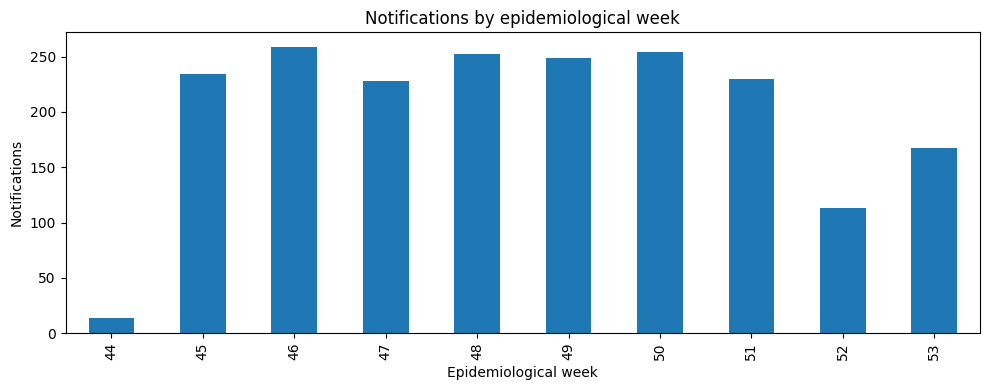

In [16]:
if not by_epiweek.empty:
    axis = by_epiweek.plot(
        x="se_notif",
        y="notifications",
        kind="bar",
        legend=False,
        figsize=(10, 4),
    )
    axis.set_title("Notifications by epidemiological week")
    axis.set_xlabel("Epidemiological week")
    axis.set_ylabel("Notifications")
    plt.tight_layout()


In [17]:
if not df_pages.empty and "nm_bairro" in df_pages:
    top_neighborhoods = (
        df_pages["nm_bairro"]
        .fillna("Unknown")
        .value_counts()
        .head(15)
        .rename_axis("neighborhood")
        .reset_index(name="notifications")
    )
else:
    top_neighborhoods = pd.DataFrame(columns=["neighborhood", "notifications"])

top_neighborhoods


,neighborhood,notifications
0,SANTA CRUZ,132
1,GUARATIBA,109
2,CAMPO GRANDE,105
3,TIJUCA,67
4,BANGU,65
5,BENFICA,53
6,RAMOS,40
7,INHOAIBA,39
8,RECREIO DOS BANDEIRANTES,35
9,REALENGO,35


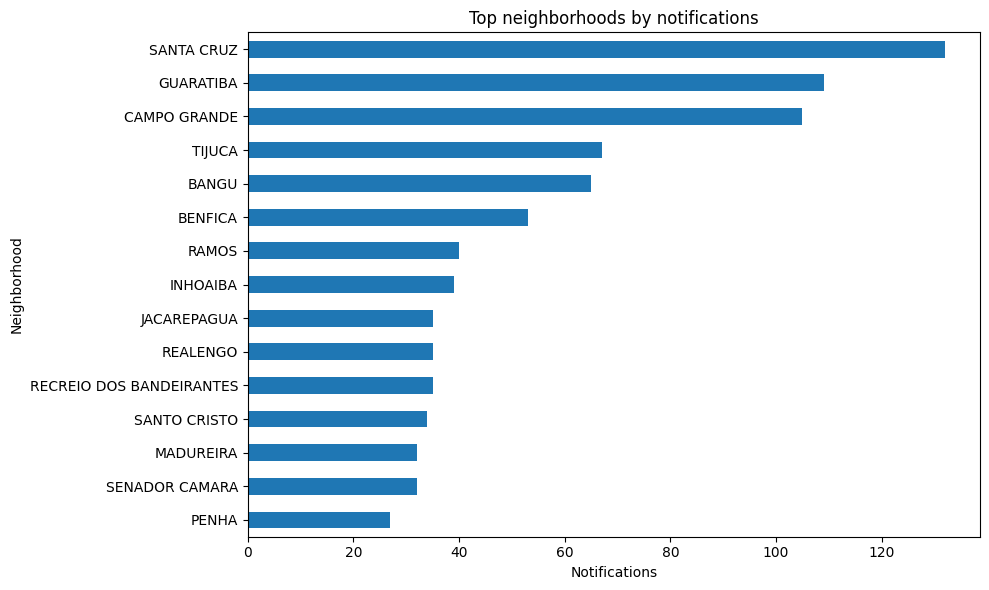

In [18]:
if not top_neighborhoods.empty:
    axis = top_neighborhoods.sort_values("notifications").plot(
        x="neighborhood",
        y="notifications",
        kind="barh",
        legend=False,
        figsize=(10, 6),
    )
    axis.set_title("Top neighborhoods by notifications")
    axis.set_xlabel("Notifications")
    axis.set_ylabel("Neighborhood")
    plt.tight_layout()


## 7. Compare diseases or years

In [19]:
comparison_frames: list[pd.DataFrame] = []

for disease in ["A90", "A92"]:
    page = get_notification_pages(
        session,
        config,
        municipio_geocodigo=3304557,
        cid10=disease,
        year=2025,
        page_size=500,
        max_rows=1_000,
    )
    if not page.empty:
        page = page.assign(requested_cid10=disease)
        comparison_frames.append(page)

comparison_df = (
    pd.concat(comparison_frames, ignore_index=True)
    if comparison_frames
    else pd.DataFrame()
)

if not comparison_df.empty:
    (
        comparison_df.groupby(["requested_cid10", "se_notif"])
        .size()
        .reset_index(name="notifications")
        .sort_values(["requested_cid10", "se_notif"])
        .head(20)
    )
else:
    comparison_df


## 8. Notes

- Keep `limit` conservative when exploring the endpoint interactively.
- Use `include_count=True` only when the total number of matching rows is needed.
- Never store real tokens directly in notebooks committed to the repository.
